## 1. 지역별 총인구수 Top5

In [ ]:
import pandas as pd


file_path = 'data/인구현황.csv'
df = pd.read_csv(file_path, encoding='utf-8')
df_local = df[df['행정기관'] != '전국'].copy()

# 필요한 컬럼 선택
df_result = df_local[['행정기관', '총인구수']]

# 총인구수 기준으로 내림차순 정렬 
df_sorted = df_result.sort_values(by='총인구수', ascending=False)

# 5. 상위 5개 지역 추출
top5_regions = df_sorted.head(5)

# 6. 인덱스 정리 (깔끔하게 보이기 위해)
# 예시 이미지처럼 기존 인덱스를 유지하고 싶다면 이 줄은 건너뛰어도 됩니다.
# top5_regions = top5_regions.reset_index(drop=True)

# 결과 출력
print("=== 지역별 총인구수 Top 5 ===")
top5_regions

=== 지역별 총인구수 Top 5 ===


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


## 1-1. 지역별 총인구수 plot

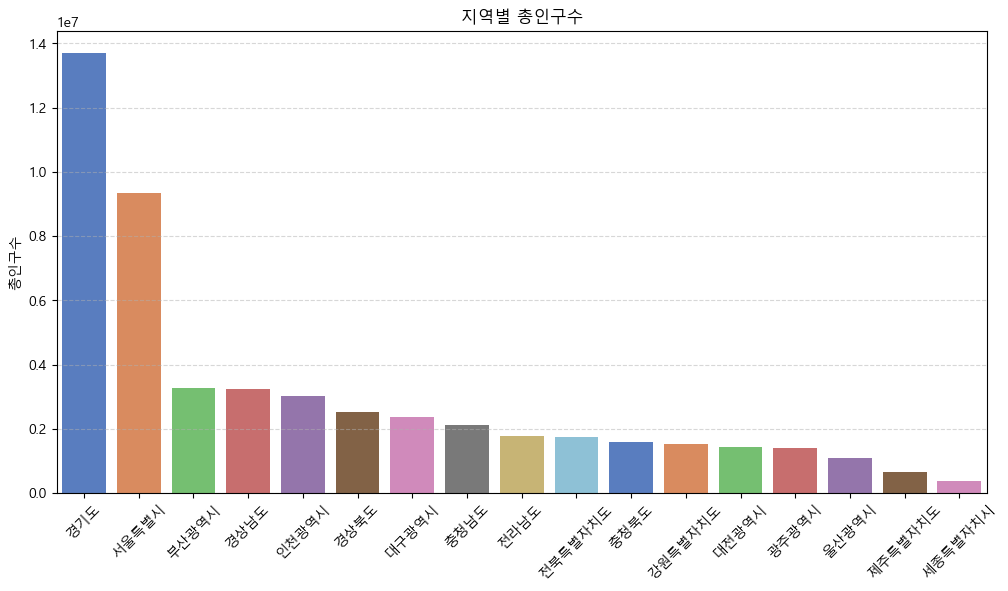

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 2. 데이터 준비 (전국 제외 & 내림차순 정렬)
# df는 이전 단계에서 불러온 데이터프레임입니다.
df_local = df[df['행정기관'] != '전국'].copy()
df_sorted = df_local.sort_values(by='총인구수', ascending=False)

# 3. 그래프 그리기
plt.figure(figsize=(12, 6)) # 그래프 크기 설정 (가로, 세로)

# Seaborn barplot 사용
sns.barplot(data=df_sorted, x='행정기관', y='총인구수', palette='muted')

# 4. 그래프 꾸미기
plt.title('지역별 총인구수') # 제목
plt.xlabel('') # x축 라벨(행정기관)은 이름이 기니까 생략하거나 비워둠
plt.ylabel('총인구수') # y축 라벨
plt.xticks(rotation=45) # x축 글씨가 겹치지 않게 45도 회전
plt.grid(axis='y', linestyle='--', alpha=0.5) # y축 눈금선 추가 (보기 편하게)

# 출력
plt.show()

## 2. 세대당 인구수 높은 지역 Top5

In [ ]:

df_household_sorted = df_local[['행정기관', '세대당 인구']].sort_values(by='세대당 인구', ascending=False)

top5_household = df_household_sorted.head(5).reset_index(drop=True)

print("=== 세대당 인구수 높은 지역 Top 5 ===")
top5_household

=== 세대당 인구수 높은 지역 Top 5 ===


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


## 2-1. 지역별 세대당 인구 Plot

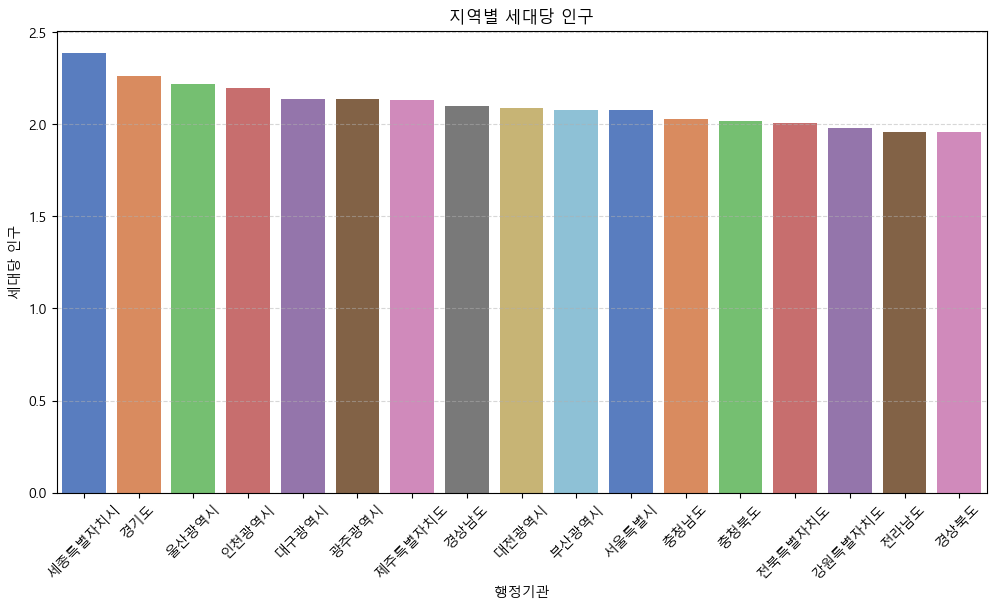

In [ ]:

df_sorted = df_local.sort_values(by='세대당 인구', ascending=False)


plt.figure(figsize=(12, 6)) 


sns.barplot(data=df_sorted, x='행정기관', y='세대당 인구', palette='muted')


plt.title('지역별 세대당 인구')
plt.xlabel('행정기관')
plt.ylabel('세대당 인구')
plt.xticks(rotation=45) # 지역 이름이 겹치지 않게 회전
plt.grid(axis='y', linestyle='--', alpha=0.5) # y축 보조선


plt.show()

## 3. 남녀 비율 분석

In [11]:
# 2. 필요한 컬럼 선택 & 정렬 (남여 비율 내림차순)
df_ratio_sorted = df_local[['행정기관', '남여 비율']].sort_values(by='남여 비율', ascending=False)

# 3. 인덱스 초기화 (0부터 순서대로)
df_ratio_result = df_ratio_sorted.reset_index(drop=True)

# 결과 출력
print("=== 남녀 비율 분석 ===")
df_ratio_result

=== 남녀 비율 분석 ===


,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


## 3-1. 남녀 비율 분석 Plot

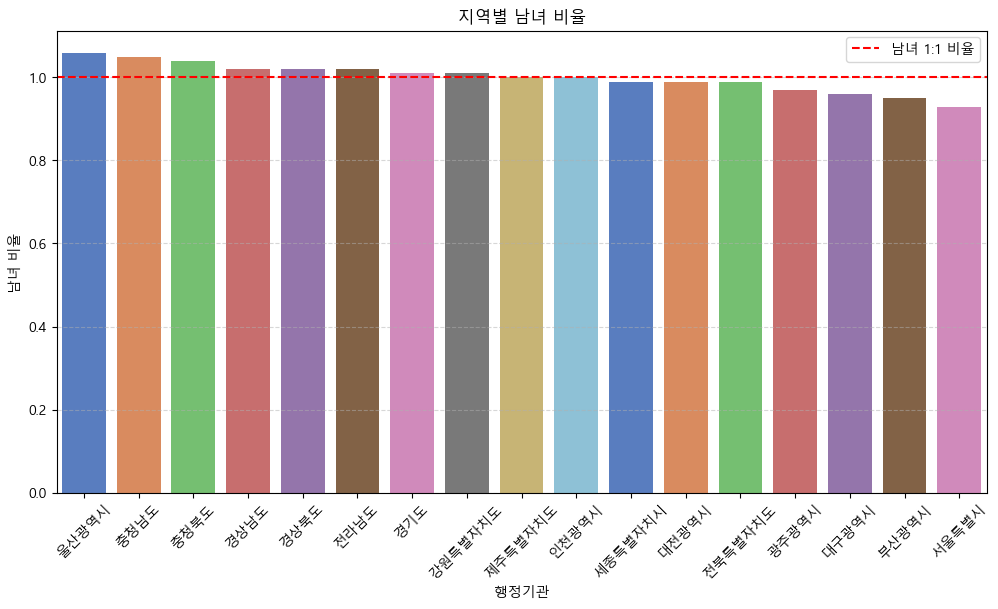

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_ratio_sorted, x='행정기관', y='남여 비율', palette='muted')

plt.axhline(y=1.0, color='r', linestyle='--', label='남녀 1:1 비율')


plt.title('지역별 남녀 비율')
plt.xlabel('행정기관')
plt.ylabel('남녀 비율')
plt.xticks(rotation=45) 
plt.legend() 
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()

## 4. 남자초과 / 여자초과 분석

In [ ]:
df_local = df[df['행정기관'] != '전국'].copy()

# 2. '남초여초' 컬럼 생성 (조건에 따른 값 부여)
# lambda 함수를 사용하여 한 줄로 처리할 수 있습니다.
df_local['남초여초'] = df_local['남여 비율'].apply(
    lambda x: '남초' if x > 1.00 else ('여초' if x < 1.00 else '동일')
)

# 3. 필요한 컬럼만 선택하여 출력
# 예시 이미지처럼 인덱스 순서(지역 순서) 그대로 출력합니다.
cols = ['행정기관', '남여 비율', '남초여초']
print("=== 남자초과 / 여자초과 분석 ===")
df_local[cols]

=== 남자초과 / 여자초과 분석 ===


,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


## 5. 세대당 인구 평균보다 높은 지역

In [14]:
# 1. 전국 제외 데이터 준비
df_local = df[df['행정기관'] != '전국'].copy()

# 2. 세대당 인구 평균 구하기
mean_val = df_local['세대당 인구'].mean()
print(f"전국 평균 세대당 인구수: {mean_val:.2f}")

# 3. 평균보다 높은 지역 필터링
df_high_mean = df_local[df_local['세대당 인구'] > mean_val].copy()

# 4. 정렬 (높은 순서대로) 및 인덱스 초기화
df_high_mean = df_high_mean.sort_values(by='세대당 인구', ascending=False).reset_index(drop=True)

# 결과 출력
print("=== 세대당 인구 평균보다 높은 지역 ===")
df_high_mean[['행정기관', '세대당 인구']]

전국 평균 세대당 인구수: 2.11
=== 세대당 인구 평균보다 높은 지역 ===


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


## 5-1.   남초 vs 여초 개수 Plot  ( seaborn의 countplot )
         지역별 세대수 Plot ( seaborn의 barplot )


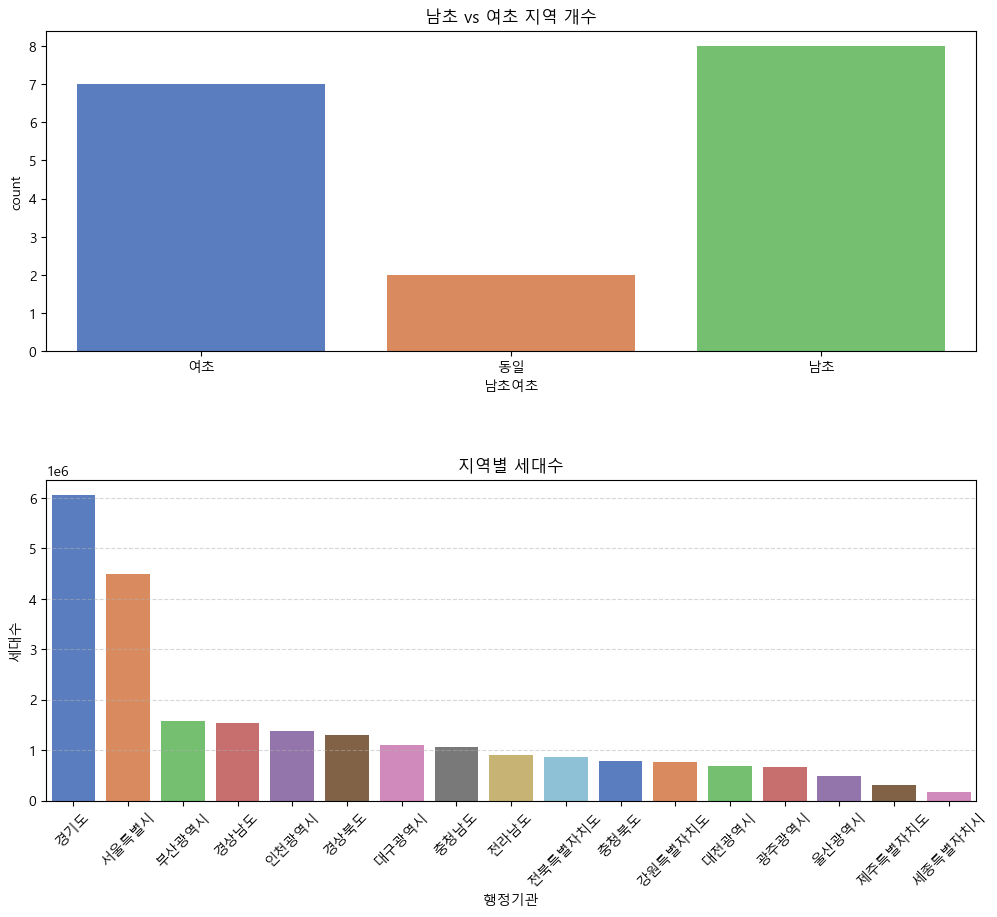

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (전국 제외)
df_local = df[df['행정기관'] != '전국'].copy()

# 2. '남초여초' 컬럼 생성 (4번 문제에서 안 만들었을 경우를 대비해 다시 작성)
df_local['남초여초'] = df_local['남여 비율'].apply(
    lambda x: '남초' if x > 1.00 else ('여초' if x < 1.00 else '동일')
)

# 3. 그래프 그리기 설정 (2행 1열)
# figsize=(12, 10): 가로 12, 세로 10 크기
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4) # 그래프 사이 간격 넓히기

# === 첫 번째 그래프: 남초 vs 여초 지역 개수 (Countplot) ===
# countplot: 데이터의 개수를 자동으로 세어서 막대로 그려줌
sns.countplot(data=df_local, x='남초여초', palette='muted', ax=ax[0])
ax[0].set_title('남초 vs 여초 지역 개수')
ax[0].set_ylabel('count')

# === 두 번째 그래프: 지역별 세대수 (Barplot) ===
# (1) 세대수 기준으로 내림차순 정렬
df_house_sorted = df_local.sort_values(by='세대수', ascending=False)

# (2) 막대그래프 그리기
sns.barplot(data=df_house_sorted, x='행정기관', y='세대수', palette='muted', ax=ax[1])
ax[1].set_title('지역별 세대수')
ax[1].tick_params(axis='x', rotation=45) # x축 글씨 45도 회전 (겹침 방지)
ax[1].grid(axis='y', linestyle='--', alpha=0.5) # y축 점선 추가

# 출력
plt.show()

## 6. 남자 인구 vs 여자 인구 비교 Plot ( 선택 )

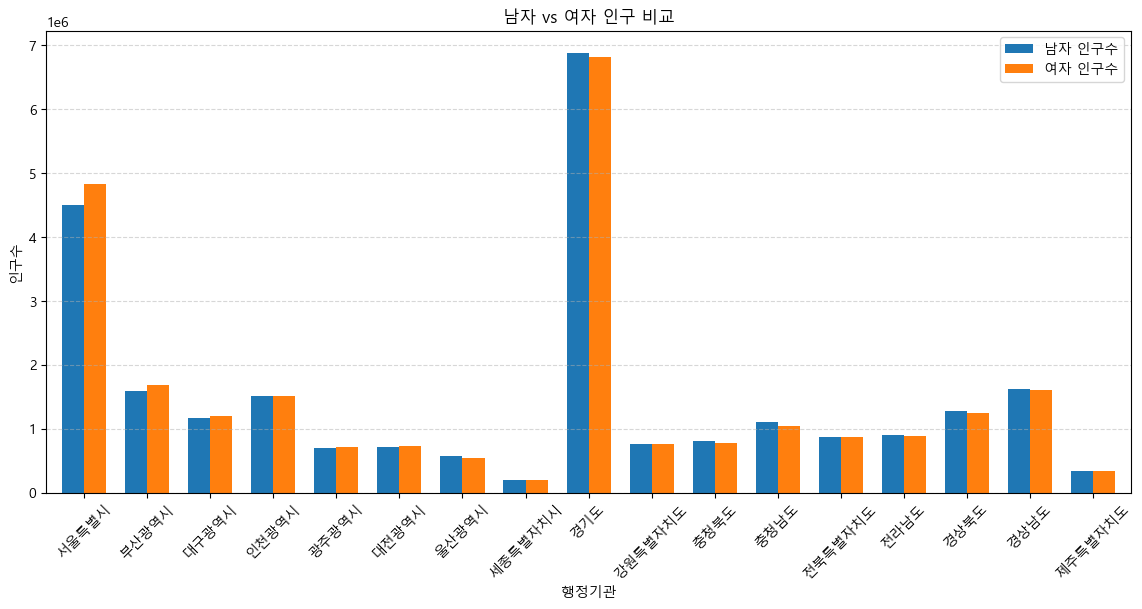

In [19]:
import matplotlib.pyplot as plt

# 1. 데이터 준비 ('전국' 데이터 제외)
df_local = df[df['행정기관'] != '전국'].copy()

# 2. 데이터 가공 (핵심 단계)
# (1) '행정기관'을 인덱스로 설정합니다. (그래프의 x축 이름으로 사용하기 위함)
# (2) 필요한 '남자 인구수', '여자 인구수' 컬럼만 뽑아옵니다.
df_compare = df_local.set_index('행정기관')[['남자 인구수', '여자 인구수']]

# 3. 그래프 그리기 (Pandas 내장 기능 활용)
# kind='bar': 막대그래프
# figsize: 그래프 크기 (가로, 세로)
# width: 막대 두께 (0.7~0.8 정도가 적당함)
ax = df_compare.plot(kind='bar', figsize=(14, 6), width=0.7)

# 4. 그래프 꾸미기
plt.title('남자 vs 여자 인구 비교')
plt.xlabel('행정기관')
plt.ylabel('인구수')
plt.xticks(rotation=45)       # x축 지역명 45도 회전
plt.legend(title='')          # 범례(Legend) 제목 제거 (깔끔하게)
plt.grid(axis='y', linestyle='--', alpha=0.5) # y축 점선 추가

# 출력
plt.show()